<a href="https://colab.research.google.com/github/aleakucing/Pembelajaran-Memsin/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [3]:
train_dir = '/content/drive/MyDrive/PemMes/JS6/images/test'
test_dir = '/content/drive/MyDrive/PemMes/JS6/images/training/'

In [4]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

In [5]:
train_img = load_dataset(train_dir)
train_img[0]

(array([[[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        ...,
 
        [[ 68,  80,  80],
         [ 68,  80,  80],
         [ 68,  80,  80],
         ...,
         [ 44,  46,  41],
         [ 46,  48,  43],
         [ 48,  50,  45]],
 
        [[ 65,  77,  77],
         [ 66,  78,  78],
         [ 66,  78,  78],
         ...,
         [ 43,  45,  40],
         [ 48,  50,  45],
         [ 53,  55,  50]],
 
        [[ 67,  79,  79],
         [ 70,  82,  82],
         [ 72,  84,  84],
         ...,
         [ 46,  48,  43],
  

In [6]:
pick_random = np.random.randint(0, len(train_img))

# Check img size
print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 71
(439, 640, 3)


In [7]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (593, 800, 3)
Label	: day


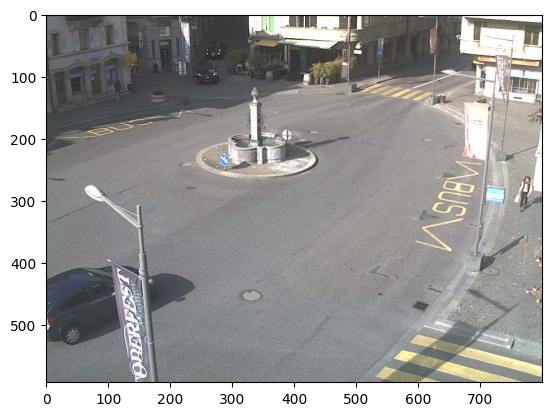

In [8]:
random_img_viz(train_img)

In [9]:
#3 - pra pengolahan data
def standarized_input(image):
    # resize to w: 1100, h:600
    std_img = cv2.resize(image, (1100,600))

    return std_img

In [10]:
#lakukan encoding
def label_encoder(label):
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

In [11]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        std_img = standarized_input(image)

        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

In [12]:
train_std_img_list = preprocess(train_img)

In [13]:
pick_random = np.random.randint(0, len(train_std_img_list))

print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 28
(600, 1100, 3)


In [14]:
#4 - ektrasi fitur
def avg_brightness(image):
    # Convert image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Calculate the avg of brightness
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg

Image 97
Avg Brighness: 82.3673


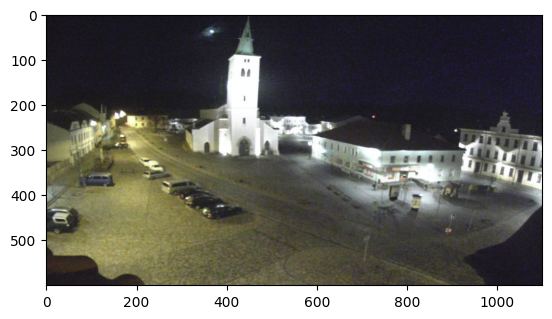

In [15]:
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

In [16]:
#5 - klasifikasi metode threshold
def predict_label(img, threshold):
    # Computer average brightness
    avg = avg_brightness(img)
    pred = 0

    # Predict the label based on user defined threshold
    if avg > threshold:
        pred = 1

    return pred

Image 24
Actual label: 1
Predicted label: 1


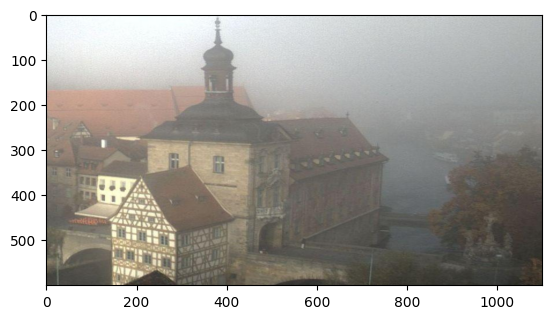

In [17]:
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

# Evaluate
print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

In [18]:
#6 - Evaluasi Manual
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:
        # Get the ground truth / correct label
        img = file[0]
        label = file[1]

        # Get prediction
        pred_label = predict_label(img, threshold)

        # Compare ground truth and pred
        if pred_label != label:
            miss_labels.append((img, pred_label, label))

    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img
    print(f'Accuracy: {accuracy:.4f}')

In [19]:
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8688


In [20]:
test_img = load_dataset(test_dir)

test_std_img_list = preprocess(test_img)

evaluate(test_std_img_list, threshold=120)


Accuracy: 0.8417


In [21]:
#4 Alternatif - Membuat Feature Vectors
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
        img_label = img[1] # Get the image label

        avg_list.append(img_avg)
        labels.append(img_label)

    # Stack data in columcular way
    data = np.column_stack((avg_list, labels))
    # Create a Pandas dataframe
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

In [22]:
#hasil
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,157.186358,1.0
1,184.670024,1.0
2,125.659120,1.0
3,127.443791,1.0
4,185.917073,1.0


In [23]:
#hasil pada data testing
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,111.492982,0.0
1,33.761653,0.0
2,25.715848,0.0
3,91.782092,0.0
4,39.105368,0.0


In [24]:
#5 buat mode svm
from sklearn.svm import SVC

# Split data and label
X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

In [25]:
#evaluasi
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.925
Accuracy on test: 0.9083333333333333
